<a href="https://colab.research.google.com/github/FlareSome/MNIST_NeuralNetwork/blob/main/codespace/MNIST_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import time

In [54]:
def convertUbyteToCSV(images, labels, outfile, n):
    with open(images, "rb") as imgf:
        imgf.read(16)

        with open(labels, "rb") as labelf:
            labelf.read(8)
            imgs = []
            for i in range(n):
                img = [ord(labelf.read(1))]
                for j in range(28*28):
                    img.append(ord(imgf.read(1)))
                imgs.append(img)

            with open(outfile, "w") as csvf:
                for image in imgs:
                    csvf.write(",".join(str(pix) for pix in image)+"\n")


In [55]:
mnist_train_x = "/home/flaresome/Project/Neural_Networks/datasets/train-images.idx3-ubyte"
mnist_train_y = "/home/flaresome/Project/Neural_Networks/datasets/train-labels.idx1-ubyte"
mnist_test_x = "/home/flaresome/Project/Neural_Networks/datasets/t10k-images.idx3-ubyte"
mnist_test_y = "/home/flaresome/Project/Neural_Networks/datasets/t10k-labels.idx1-ubyte"

In [56]:
convertUbyteToCSV(
    mnist_train_x,
    mnist_train_y,
    "/home/flaresome/Project/Neural_Networks/datasets/train.csv",
    60000
    )
convertUbyteToCSV(
    mnist_test_x,
    mnist_test_y,
    "/home/flaresome/Project/Neural_Networks/datasets/test.csv",
    10000
    )

In [57]:
with open("/home/flaresome/Project/Neural_Networks/datasets/train.csv", "r") as train_file:
    train_list = train_file.readlines()
print(len(train_list))

60000


In [58]:
train_list[100]

'5,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,18,46,136,136,244,255,241,103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,15,94,163,253,253,253,253,238,218,204,35,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,131,253,253,253,253,237,200,57,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,155,246,253,247,108,65,45,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,207,253,253,230,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,157,253,253,125,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,253,250,57,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,253,247,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,253,247,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,89,253,247,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

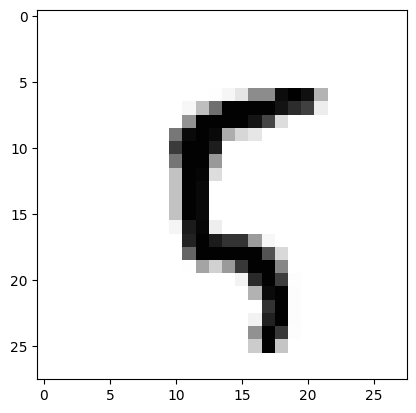

In [59]:
values  = train_list[100].split(",")
image_array = np.asarray(values[1:], dtype = float).reshape((28, 28))
plt.imshow(image_array, cmap = "Greys", interpolation = "none")

In [60]:
with open("/home/flaresome/Project/Neural_Networks/datasets/test.csv", "r") as test_file:
    test_list = test_file.readlines()
print(len(test_list))

10000


In [61]:
class DNN:
    def __init__(self, sizes = [784, 128, 64, 10], epochs = 10, lr = 0.01):
        self.sizes = sizes
        self.epochs = epochs
        self.lr = lr

        self.loss_history = []
        self.accuracy_history = []

        input_layer = sizes[0]
        hidden_1 = sizes[1]
        hidden_2 = sizes[2]
        output_layer = sizes[3]

#        self.params = {
#            'W1' : np.random.randn(hidden_1, input_layer) * np.sqrt(1. / hidden_1), #128 x 784
#            'W2' : np.random.randn(hidden_2, hidden_1) * np.sqrt(1. / hidden_2),    #64 x 128
#            'W3' : np.random.randn(output_layer, hidden_2) * np.sqrt(1. / output_layer) #10 x 64
#        }

        self.params = {
            'W1': np.random.randn(hidden_1, input_layer) *
                np.sqrt(2.0 / (input_layer + hidden_1)),

            'W2': np.random.randn(hidden_2, hidden_1) *
                np.sqrt(2.0 / (hidden_1 + hidden_2)),

            'W3': np.random.randn(output_layer, hidden_2) *
                np.sqrt(2.0 / (hidden_2 + output_layer))
        }

#    def sigmoid(self, x, derivative = False):
#        if derivative:
#            return (np.exp(-x)) / ((np.exp(-x)+1)**2)
#        return 1 / (1 +np.exp(-x))

    def relu(self, x, derivative=False):
        if derivative:
            return (x > 0).astype(float)
        return np.maximum(0, x)

    def softmax(self, x, derivative = False):
        exps = np.exp(x - x.max())
        if derivative:
            return exps / np.sum(exps, axis = 0) *(1 - exps / np.sum(exps, axis = 0))
        return exps / np.sum(exps, axis = 0)

    def forward_pass(self, x_train):
        params = self.params

        params['A0'] = x_train

        #input to hidden layer 1
        params['Z1'] = np.dot(params['W1'], params['A0'])
#        params['A1'] = self.sigmoid(params['Z1'])
        params['A1'] = self.relu(params['Z1'])

        #hidden layer 1 to hidden layer 2
        params['Z2'] = np.dot(params['W2'], params['A1'])
#        params['A2'] = self.sigmoid(params['Z2'])
        params['A2'] = self.relu(params['Z2'])

        #hidden layer 2 to output_layer
        params['Z3'] = np.dot(params['W3'], params['A2'])
        params['A3'] = self.softmax(params['Z3'])

        return params['A3']

    def backward_pass(self, y_train, output):
        params = self.params

        change_w = {}

        #calculate W3 Update
        error = 2 * (output - y_train) / output.shape[0] * self.softmax(params['Z3'], derivative = True)
        change_w['W3'] = np.outer(error, params['A2'])

        #calculate W2 Update
        error = np.dot(params['W3'].T, error) * self.relu(params['Z2'], derivative = True)
        change_w['W2'] = np.outer(error, params['A1'])

        #calculate W1 Update
        error = np.dot(params['W2'].T, error) * self.relu(params['Z1'], derivative = True)
        change_w['W1'] = np.outer(error, params['A0'])

        return change_w
    
    def update_weights(self, change_w):
        for key, val in change_w.items():
            self.params[key] -= self.lr * val  #W_t+1 = W_t - (lr * delta(W_t))

    def compute_accuracy(self, test_data):
        predictions = []

        for x in test_data:
            values = x.split(",")
            inputs = (np.asarray(values[1:], dtype = float) / 255.0 *  0.99) + 0.01
            targets = np.zeros(10) + 0.01
            targets[int(values[0])] = 0.99
            output = self.forward_pass(inputs)
            pred = np.argmax(output)
            predictions.append(pred == np.argmax(targets))

        return np.mean(predictions)

    def predict_proba(self, test_data):
        probabilities = []
        actual_labels = []

        for x in test_data:
            values = x.split(",")

            inputs = (
                np.asarray(values[1:], dtype=float) / 255.0 * 0.99
            ) + 0.01

            output = self.forward_pass(inputs)

            probabilities.append(output)
            actual_labels.append(int(values[0]))

        return np.array(probabilities), np.array(actual_labels)

    def train(self, train_list, test_list):
        for i in range(self.epochs):

            start_time = time.time()
            total_loss = 0

            for x in train_list:

                values = x.split(",")

                inputs = (
                    np.asarray(values[1:], dtype=float) / 255.0 * 0.99
                ) + 0.01

                targets = np.zeros(10) + 0.01
                targets[int(values[0])] = 0.99

                output = self.forward_pass(inputs)

                loss = -np.sum(targets * np.log(output + 1e-8))
                total_loss += loss

                change_w = self.backward_pass(targets, output)
                self.update_weights(change_w)

            accuracy = self.compute_accuracy(test_list)

            average_loss = total_loss / len(train_list)

            self.loss_history.append(average_loss)
            self.accuracy_history.append(accuracy)

            print(
                f"Epoch: {i+1}, "
                f"Time Spent: {time.time()-start_time:.2f}s, "
                f"Loss: {average_loss:.4f}, "
                f"Accuracy: {accuracy*100:.2f}%"
            )

In [ ]:
dnn = DNN(sizes = [784, 128, 64, 10], epochs = 10, lr = 0.005)
#dnn.train(train_list, test_list)

Epoch: 1, Time Spent: 22.15s, Loss: 1.4536, Accuracy: 83.95%
Epoch: 2, Time Spent: 22.72s, Loss: 1.1973, Accuracy: 88.84%
Epoch: 3, Time Spent: 23.46s, Loss: 1.1638, Accuracy: 90.24%
Epoch: 4, Time Spent: 23.62s, Loss: 1.1521, Accuracy: 90.91%
Epoch: 5, Time Spent: 23.78s, Loss: 1.1473, Accuracy: 91.77%
Epoch: 6, Time Spent: 23.82s, Loss: 1.1401, Accuracy: 92.36%
Epoch: 7, Time Spent: 24.03s, Loss: 1.1345, Accuracy: 92.97%
Epoch: 8, Time Spent: 24.71s, Loss: 1.1321, Accuracy: 93.53%
Epoch: 9, Time Spent: 24.07s, Loss: 1.1311, Accuracy: 93.82%
Epoch: 10, Time Spent: 24.78s, Loss: 1.1303, Accuracy: 94.21%


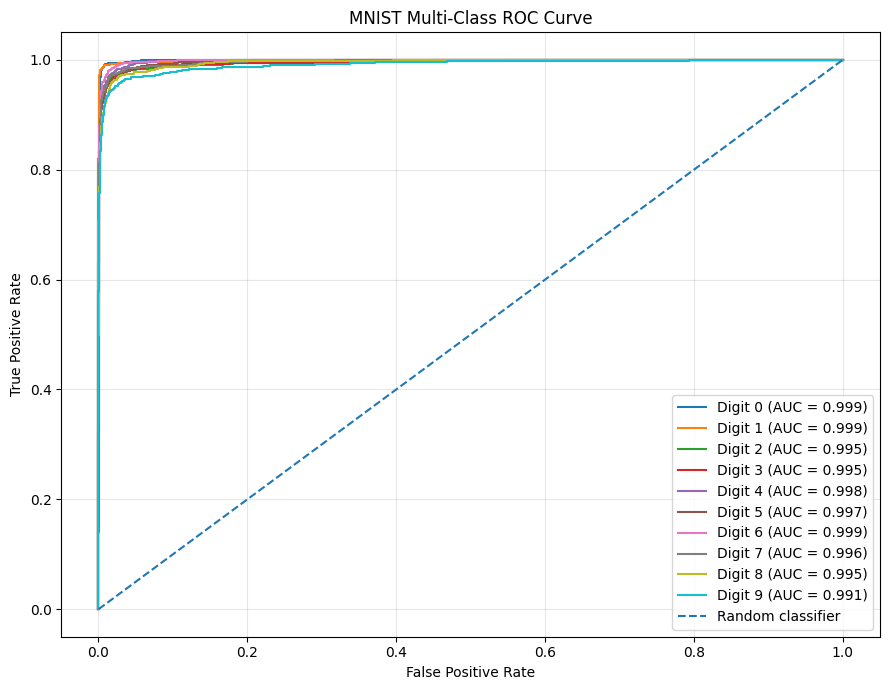

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import os
os.makedirs("../images", exist_ok=True)

y_score, y_test = dnn.predict_proba(test_list)

y_test_bin = label_binarize(
    y_test,
    classes=np.arange(10)
)

plt.figure(figsize=(9, 7))

for i in range(10):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Digit {i} (AUC = {roc_auc:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("MNIST Multi-Class ROC Curve")

plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.savefig("../images/roc_curve.png", dpi=300, bbox_inches="tight")

plt.show()

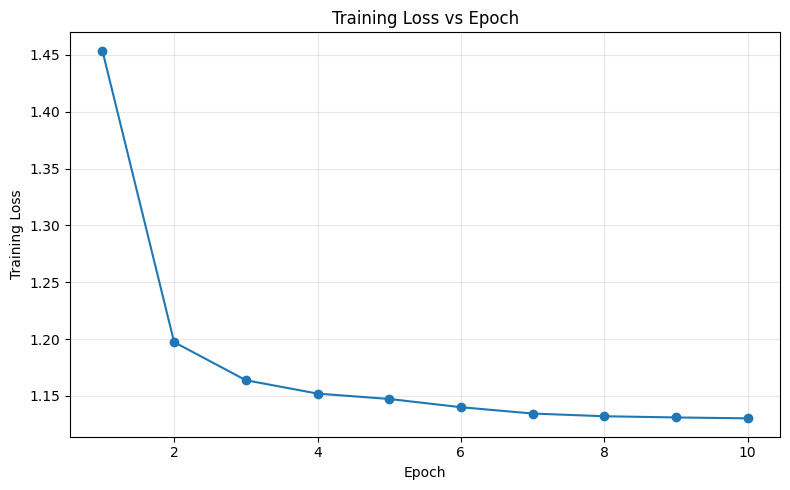

In [68]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, dnn.epochs + 1),
    dnn.loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epoch")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("../images/training_loss.png", dpi=300, bbox_inches="tight")

plt.show()

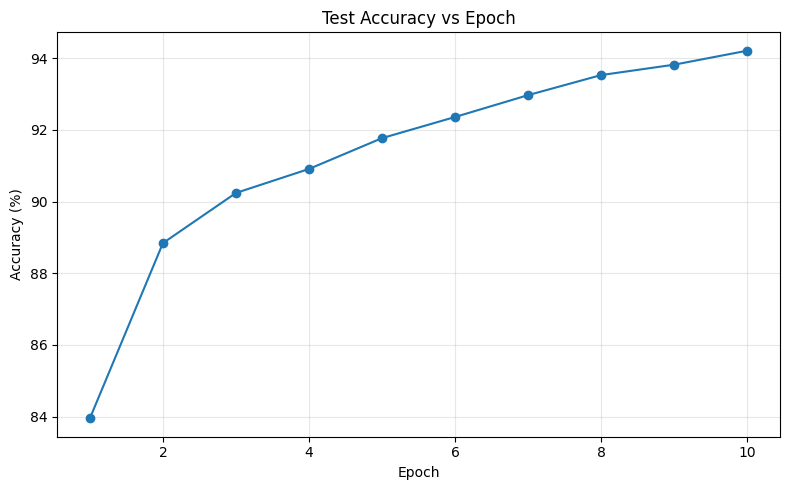

In [69]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, dnn.epochs + 1),
    np.array(dnn.accuracy_history) * 100,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Test Accuracy vs Epoch")

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig("../images/accuracy_curve.png", dpi=300, bbox_inches="tight")

plt.show()


Testing: ../datasets/image/1.png


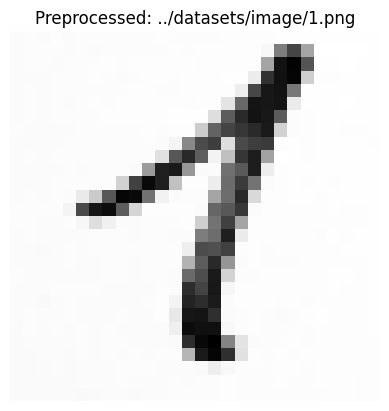

Predicted Digit: 9

Class Probabilities:
Digit 0: 0.05%
Digit 1: 0.00%
Digit 2: 0.00%
Digit 3: 0.04%
Digit 4: 10.43%
Digit 5: 5.84%
Digit 6: 0.01%
Digit 7: 10.33%
Digit 8: 21.73%
Digit 9: 51.57%

Testing: ../datasets/image/2.png


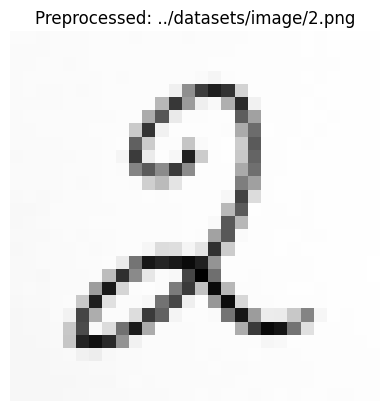

Predicted Digit: 2

Class Probabilities:
Digit 0: 0.67%
Digit 1: 0.10%
Digit 2: 92.30%
Digit 3: 0.81%
Digit 4: 0.05%
Digit 5: 0.91%
Digit 6: 0.94%
Digit 7: 0.14%
Digit 8: 4.07%
Digit 9: 0.02%

Testing: ../datasets/image/3.png


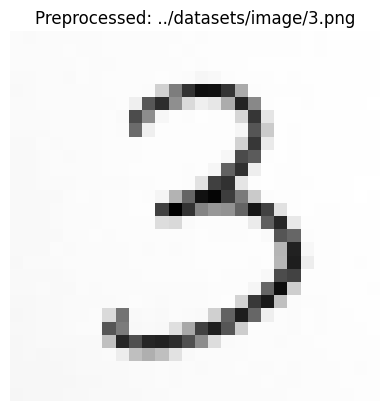

Predicted Digit: 3

Class Probabilities:
Digit 0: 0.03%
Digit 1: 0.05%
Digit 2: 0.13%
Digit 3: 97.52%
Digit 4: 0.00%
Digit 5: 1.51%
Digit 6: 0.00%
Digit 7: 0.00%
Digit 8: 0.74%
Digit 9: 0.00%

Testing: ../datasets/image/4.png


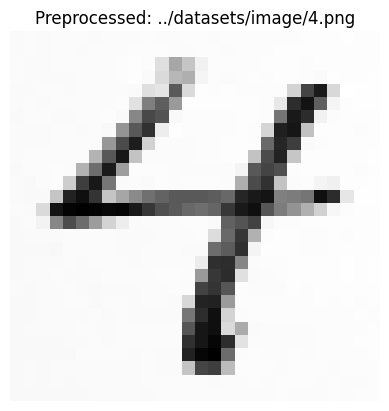

Predicted Digit: 4

Class Probabilities:
Digit 0: 0.05%
Digit 1: 0.00%
Digit 2: 0.00%
Digit 3: 0.10%
Digit 4: 66.88%
Digit 5: 1.23%
Digit 6: 0.01%
Digit 7: 7.33%
Digit 8: 18.29%
Digit 9: 6.12%

Testing: ../datasets/image/5.png


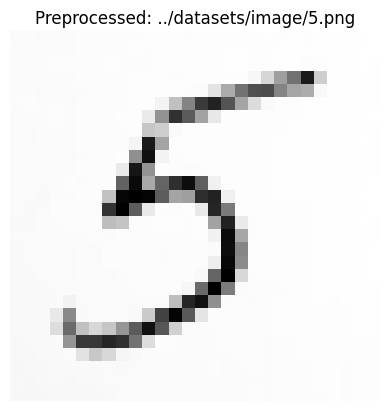

Predicted Digit: 5

Class Probabilities:
Digit 0: 0.25%
Digit 1: 0.02%
Digit 2: 0.00%
Digit 3: 0.43%
Digit 4: 1.93%
Digit 5: 88.67%
Digit 6: 1.55%
Digit 7: 0.06%
Digit 8: 6.41%
Digit 9: 0.69%

Testing: ../datasets/image/6.png


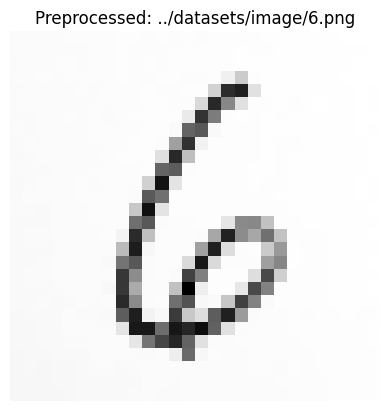

Predicted Digit: 5

Class Probabilities:
Digit 0: 9.45%
Digit 1: 0.01%
Digit 2: 6.52%
Digit 3: 0.35%
Digit 4: 0.44%
Digit 5: 54.30%
Digit 6: 23.27%
Digit 7: 0.02%
Digit 8: 5.64%
Digit 9: 0.01%

Testing: ../datasets/image/7.png


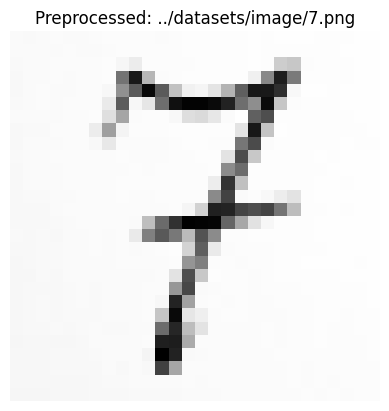

Predicted Digit: 3

Class Probabilities:
Digit 0: 0.03%
Digit 1: 1.53%
Digit 2: 15.76%
Digit 3: 40.97%
Digit 4: 0.22%
Digit 5: 3.13%
Digit 6: 1.48%
Digit 7: 0.01%
Digit 8: 36.78%
Digit 9: 0.08%

Testing: ../datasets/image/8.png


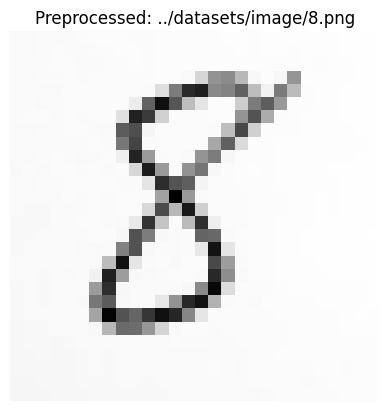

Predicted Digit: 5

Class Probabilities:
Digit 0: 2.30%
Digit 1: 0.01%
Digit 2: 5.43%
Digit 3: 2.13%
Digit 4: 0.00%
Digit 5: 80.85%
Digit 6: 1.91%
Digit 7: 0.00%
Digit 8: 7.37%
Digit 9: 0.00%

Testing: ../datasets/image/9.png


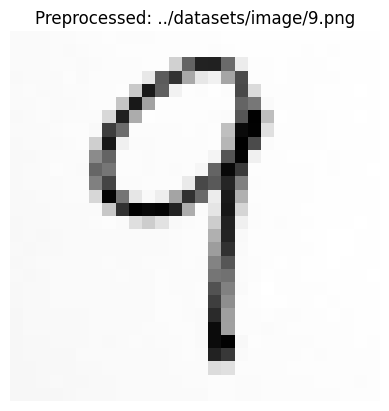

Predicted Digit: 3

Class Probabilities:
Digit 0: 0.47%
Digit 1: 0.27%
Digit 2: 0.13%
Digit 3: 33.75%
Digit 4: 6.03%
Digit 5: 26.88%
Digit 6: 0.11%
Digit 7: 1.30%
Digit 8: 28.99%
Digit 9: 2.08%


In [70]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from glob import glob

image_paths = sorted(glob("../datasets/image/[1-9].png"))

for image_path in image_paths:

    print(f"\n{'=' * 40}")
    print(f"Testing: {image_path}")
    print(f"{'=' * 40}")

    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("Error: Could not load the image.")
        continue

    img_resized = cv2.resize(
        img,
        (28, 28),
        interpolation=cv2.INTER_AREA
    )

    if np.mean(img_resized) > 127:
        img_resized = cv2.bitwise_not(img_resized)

    plt.imshow(img_resized, cmap="Greys")
    plt.title(f"Preprocessed: {image_path}")
    plt.axis("off")
    plt.show()

    test_input = (img_resized.astype(float) / 255.0 * 0.99) + 0.01

    test_input = test_input.flatten()

    output = dnn.forward_pass(test_input)

    predicted_digit = np.argmax(output)

    print(f"Predicted Digit: {predicted_digit}")

    print("\nClass Probabilities:")
    for digit, prob in enumerate(output):
        print(f"Digit {digit}: {prob * 100:.2f}%")